# LSTM for Sentiment Analysis

## Here, we utilise an LSTM Model to classify the 'statement' column into it's respective classes

## Library versions to install

In [ ]:
! pip install gensim==4.3.2
! pip install scipy==1.10.1

In [ ]:
!pip install pandas==1.5.3
!pip install numpy==1.24.3
!pip install scikit-learn==1.3.2
!pip install torch==2.6.0
!pip install tqdm==4.67.1
!pip install transformers==4.49.0
! pip install nltk==3.9.1
!pip install gensim==4.1.2

## Import Libraries

In [ ]:
from gensim.models import KeyedVectors
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from torch.utils.data import TensorDataset, DataLoader
# from transformers import DistilBertTokenizer, DistilBertModel
import nltk
from nltk.tokenize import word_tokenize
from collections import Counter
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from itertools import product
import re
from sklearn.model_selection import ParameterGrid
import os
from datetime import datetime
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

nltk.download('punkt')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

# Loading Data and Splitting Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/My Drive/BT4222/data/df_feature_engineering.parquet'

df_feature_engineered = pd.read_parquet(file_path)
df_feature_engineered.head()

Mounted at /content/drive


,id,label,statement,subject,speaker,speaker_job_title,state_info,party_affiliation,barely_true_counts,false_counts,...,label_pants-fire,label_true,statement_embedding,subject_embedding,state_info_encoded,party_affiliation_encoded,speaker_job_title_embedding,context_embedding,sentiment_polarity,sentiment_subjectivity
0,7874.json,half-true,new jersey pension system solvent,"pensions,state-finances",13th district gop slate,unknown,new jersey,republican,0.0,0.0,...,0,0,"[-0.012083505280315876, 0.04291439801454544, -...","[-0.00025620736414566636, 0.07373839616775513,...",31,8,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.09551206976175308, 0.009169962257146835, 0...",0.136364,0.455
1,2287.json,pants-fire,president obama muslim,"candidates-biography,obama-birth-certificate,r...",18 percent american public,unknown,unknown,other,0.0,0.0,...,1,0,"[0.038615476340055466, 0.09793295711278915, -0...","[0.018359245732426643, -0.0027450439520180225,...",45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.024317895993590355, -0.01789085566997528, ...",0.000000,0.000
2,13412.json,true,test share fact widget,technology,18 percent american public,unknown,unknown,other,0.0,0.0,...,0,1,"[0.008107000961899757, 0.016036679968237877, -...","[-0.053375788033008575, 0.08707486093044281, -...",45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.06791266053915024, -0.015540316700935364, ...",0.000000,0.000
3,2426.json,barely-true,new health care law cut billion medicare hurt ...,"health-care,medicare,message-machine",60 plus association,unknown,unknown,other,2.0,0.0,...,0,0,"[-0.05084792524576187, 0.031769607216119766, 0...","[-0.01470591127872467, 0.015529205091297626, 0...",45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.10175436735153198, -0.002838208107277751, ...",0.136364,0.455
4,4832.json,pants-fire,independent payment advisory board created hea...,"government-regulation,health-care,message-mach...",60 plus association,unknown,unknown,other,2.0,0.0,...,1,0,"[-0.10781728476285934, 0.017993967980146408, 0...","[0.02528245933353901, 0.005831953138113022, -0...",45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.03631351888179779, 0.039651136845350266, -...",0.068182,0.290


## Label Encoding for label column

Since it is a multi-class problem and we use CrossEntropy Loss, whic is unable to take in one-hot encodings, we encode the labels with integers 0-5 instead, in order of their truthfulness with
- 0: 'pants-fire'
- 1: 'false'
- 2: 'barely-true'
- 3: 'half-true'
- 4: 'mostly-true'
- 5: 'true'

In [ ]:
# mapping it in the order of pants-fire, false, barely-true, half-true, mostly-true, true
label_order = ['pants-fire', 'false', 'barely-true', 'half-true', 'mostly-true', 'true']
label2idx = {label: idx for idx, label in enumerate(label_order)}
idx2label = {idx: label for label, idx in label2idx.items()}
df_feature_engineered['label_encoded'] = df_feature_engineered['label'].map(label2idx)

df_feature_engineered[['label', 'label_encoded']]

,label,label_encoded
0,half-true,3
1,pants-fire,0
2,true,5
3,barely-true,2
4,pants-fire,0
...,...,...
12781,false,1
12782,mostly-true,4
12783,mostly-true,4
12784,half-true,3


## Train, Validation, Test Set split

- We use the basic 80% to 20% split on train and test dataset
- Then, we split the train set by 80% to 20% again for train and validation dataset

In [ ]:
# split into train + val and test
df_train_val, df_test = train_test_split(df_feature_engineered, test_size=0.2, random_state=42)

# split train_val into train and val
df_train, df_val = train_test_split(df_train_val, test_size=0.2, random_state=42)

# Final sizes
print(f"Training set size: {len(df_train)}")
print(f"Validation set size: {len(df_val)}")
print(f"Test set size: {len(df_test)}")


Training set size: 8182
Validation set size: 2046
Test set size: 2558


## Feature Selection

- Since LSTM focuses on 'statement' itself, we select 'statement' to make up our input labels.

- 'label_encoded' is the output label.

In [ ]:
x_train = df_train[['statement']].copy()
y_train = df_train[['label_encoded']].copy()

x_val = df_val[['statement']].copy()
y_val = df_val[['label_encoded']].copy()

x_test = df_test[['statement']].copy()
y_test = df_test[['label_encoded']].copy()

x_train.shape, y_train.shape, x_val.shape, y_val.shape, x_test.shape, y_test.shape

((8182, 1), (8182, 1), (2046, 1), (2046, 1), (2558, 1), (2558, 1))

## Visualisations

### Check value counts of labels in train_df
- We check the distribution of labels in the train_df to visualize if there are any class imbalances

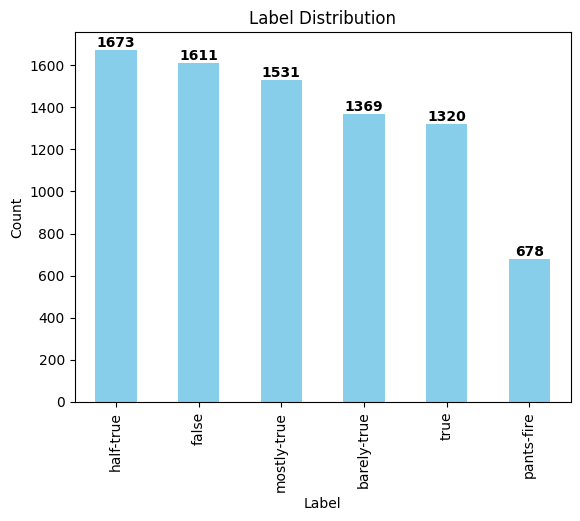

In [ ]:
ax = df_train['label'].value_counts().plot(kind='bar', color='skyblue')

plt.title('Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')

# Add count labels on top of each bar
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.show()

### Check length of statement in train_df
- We check the length of statements since it will be important for further processing of the words such as for Tokenization and Padding later on.

In [ ]:
df_train['statement_length'] = df_train['statement'].apply(lambda statement: len(statement.split(" ")))
df_train['statement_length'].describe()

,statement_length
count,8182.000000
mean,10.334759
std,5.140848
min,1.000000
25%,7.000000
50%,10.000000
75%,13.000000
max,223.000000


<Axes: >

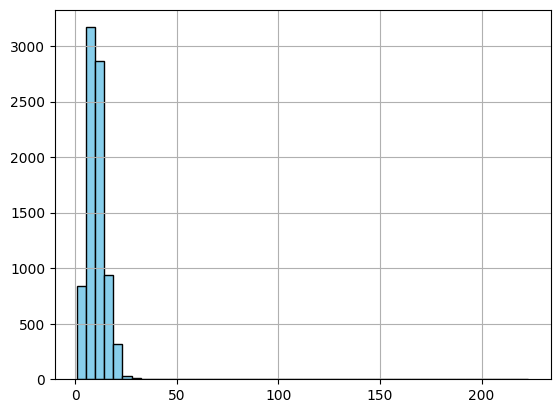

In [ ]:
df_train['statement_length'].hist(bins=50, color='skyblue', edgecolor='black')

# Tokenization and Padding

## Building a Vocabulary

- Firstly, we tokenize the text in our train, validation and test datasets by using nltk to tokenize the 'statement' column
- Then, we concatenate the tokenized statements and use the tokens to build the vocabulary
- Lastly, using the vocabulary built, we convert the tokens into indices

In [ ]:
# tokenization function
def tokenize_statements(df):
    return [nltk.word_tokenize(statement.lower()) for statement in df['statement']]

# tokenize the statements for each dataset
x_train_tokens = tokenize_statements(x_train)
x_val_tokens = tokenize_statements(x_val)
x_test_tokens = tokenize_statements(x_test)

# build vocabulary - every word gets a unique ID
def build_vocab_from_all_data(train_data, val_data, test_data):
    all_data = train_data + val_data + test_data
    all_words = [word for sentence in all_data for word in sentence]
    vocab = Counter(all_words)
    word2idx = {word: idx + 1 for idx, (word, _) in enumerate(vocab.items())}
    word2idx["<PAD>"] = 0
    word2idx["<UNK>"] = len(word2idx)
    return word2idx

word2idx = build_vocab_from_all_data(x_train_tokens, x_val_tokens, x_test_tokens)

# convert tokens to indices
def convert_to_indices(data, word2idx):
    return [[word2idx.get(word, word2idx["<UNK>"]) for word in sentence] for sentence in data]

train_data_indices = convert_to_indices(x_train_tokens, word2idx)
val_data_indices = convert_to_indices(x_val_tokens, word2idx)
test_data_indices = convert_to_indices(x_test_tokens, word2idx)

## Padding
- From above, we note that the mean number of words in a statement is 10, with 75% of statements having 13 words or less. Since we want to retain meaning, without too much padding, truncate or pad each sequence to have a length of 20.

In [ ]:
# pad sequences to a fixed length
def pad_sequences(sequences, maxlen, padding_value=0):
    return [seq[:maxlen] if len(seq) > maxlen else seq + [padding_value] * (maxlen - len(seq)) for seq in sequences]

max_length = 20
train_data_padded = pad_sequences(train_data_indices, maxlen=max_length)
val_data_padded = pad_sequences(val_data_indices, maxlen=max_length)
test_data_padded = pad_sequences(test_data_indices, maxlen=max_length)

# Using GloVe for to create an Embedding Matrix for the first layer of our Neural Network

- We load pretrained word vectors into a dictionary
- Then, we create an embedding matrix by replacing rows in word2idx with GloVe vectors where available
  - Hence, in an embedding matrix, each row corresponds to a word in the vocabulary and each column represents a dimension of the embedding (100d in our case)
  - The embedding layer will be used to convert word indices into vectors in the Neural Netword during model training
- If the word is not in the GloVe embeddings, we keep the random vector that was initialized instead


In [ ]:
# load GloVe embeddings
def load_glove_embeddings(glove_file_path, embedding_dim=100):
    embeddings_index = {}
    with open(glove_file_path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.strip().split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = vector
    return embeddings_index

def create_embedding_matrix(word2idx, embeddings_index, embedding_dim=100):
    vocab_size = len(word2idx)
    embedding_matrix = np.random.normal(0, 1, (vocab_size, embedding_dim))  # random init

    # for each word in vocab, if the word exists in GloVe file, it will be replaced with the embedding,
    # else keep the random vector
    for word, idx in word2idx.items():
        if word in embeddings_index:
            embedding_matrix[idx] = embeddings_index[word]

    return torch.tensor(embedding_matrix, dtype=torch.float)

# load glove embeddings
glove_path = '/content/drive/My Drive/BT4222/data/glove.6B.100d.txt'
# glove_path = 'glove.6B.100d.txt'
glove_embeddings = load_glove_embeddings(glove_path)

# create embedding matrix
embedding_matrix = create_embedding_matrix(word2idx, glove_embeddings, embedding_dim=100)
print(embedding_matrix.shape)
embedding_matrix

torch.Size([10825, 100])


tensor([[ 0.2068,  0.2115, -2.3363,  ..., -0.1211, -0.5286, -0.8803],
        [-0.1235,  0.5824,  0.9399,  ...,  0.1984,  0.5176,  0.1209],
        [-0.3419,  0.6998, -0.0627,  ..., -0.4356,  0.8389,  0.3164],
        ...,
        [-0.1389,  0.2052,  0.5024,  ..., -0.3543,  0.0804, -0.3550],
        [ 0.0773, -0.0221,  0.3074,  ..., -0.1931,  0.1481, -0.3868],
        [-1.0022,  0.3922,  0.9554,  ..., -0.2820,  0.5570,  0.8426]])

# Batching and Loading as Tensor

In [ ]:
from torch.utils.data import Dataset

class FakeNewsDataset(Dataset):
    def __init__(self, input_ids, labels, max_len):
        self.input_ids = input_ids
        self.labels = labels
        self.max_len = max_len

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return {
            'input_ids': torch.tensor(self.input_ids[idx], dtype=torch.long),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

### Create datasets and dataloaders

In [ ]:
# prepare data and labels
y_train_tensor = torch.tensor(y_train['label_encoded'].values, dtype=torch.long)
y_val_tensor = torch.tensor(y_val['label_encoded'].values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test['label_encoded'].values, dtype=torch.long)

train_labels = y_train_tensor.tolist()
val_labels = y_val_tensor.tolist()
test_labels = y_test_tensor.tolist()

# prepare datasets
train_dataset = FakeNewsDataset(train_data_padded, train_labels, max_len=max_length)
val_dataset = FakeNewsDataset(val_data_padded, val_labels, max_len=max_length)
test_dataset = FakeNewsDataset(test_data_padded, test_labels, max_len=max_length)

# dataLoader creation
BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

### Print a batch to check tokenization

In [ ]:
batch = next(iter(train_loader))
print('check input ids shape', batch['input_ids'].shape)  # [BATCH_SIZE, max_length]
print('check input ids', batch['input_ids'])
print('check batch shape', batch['label'].shape)  # [BATCH_SIZE]
print('check batch', batch['label'])

check input ids shape torch.Size([16, 20])
check input ids tensor([[ 556,  790, 2319, 2888,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0],
        [1315,  497,  696,   78, 1628,  471,   21,  220, 3444,  394, 7126, 1749,
         4904,    0,    0,    0,    0,    0,    0,    0],
        [ 285,  550,  115, 1158, 1801, 1393, 1802,   21, 1803,   74,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0],
        [  11, 1132, 1133, 1073, 1061, 5710,   62,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0],
        [5660,  451,   16,  867,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0],
        [ 711,  712,  398,  123,  600,  513,  382, 3237,  534, 1705,   56,    6,
          159, 6921,  220,  127,  507,    0,    0,    0],
        [ 587, 2009,  208, 1416,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,

In [ ]:
batch = next(iter(train_loader))
print(batch['input_ids'])  # [BATCH_SIZE, max_length]
# print(batch['sentiment_polarity'].shape)  # [BATCH_SIZE]
print(batch['label'].shape)  # [BATCH_SIZE]

tensor([[1319, 1295, 5059,  662,   88, 5060,  894,  600,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0],
        [  11,  771, 3411,   75,  745,  246,  220,  667,  450,  373,    6,    0,
            0,    0,    0,    0,    0,    0,    0,    0],
        [  37,  927,  208,  943,  396,  539,  195,  234,  235,   74,  378,   37,
           41, 2707,  357, 5143,  398, 1093,  208,   75],
        [  28,   29,  966, 1131, 2558,   41,   33,   44, 1130,   46,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0],
        [ 106,  372,  276,  293,    9,  340,   21,  608,  276,  293,    9,  340,
         2113,  194,  159,    0,    0,    0,    0,    0],
        [ 285,  550,  375,  978, 2024,  488, 3414, 3415, 1433, 3416,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0],
        [1223,  821, 1752, 5234,  869,  584,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0],
        [ 145,    6,   44, 

# Define Model Architecture

### Check if GPU is available

In [ ]:
# check cuda status
is_cuda = torch.cuda.is_available()

# if we have a GPU available, we'll set our device to GPU. We'll use this device variable later in our code.
if is_cuda:
    device = torch.device("cuda")
    print("GPU is available")
else:
    device = torch.device("cpu")
    print("GPU not available, CPU used")

GPU not available, CPU used


## LSTMClassifier Class

The LSTMClassifier class consists of:

1. embedding layer: converts word indices into dense vector embeddings.
- we use the embedding matrix that was already pretrained with GloVe
  - input: batch of tokenized sentences [batch size, number of tokens (max_length)]
  - output: 'embedded' [batch size, number of tokens (max_length), embedding dimension (100)]

2. LSTM layer: processes embedded sequence word by word and outputs hidden states for each time step. it is bidirectional and is able to capture both past and future context.
  - input: 'embedded' from embedding layer [batch size, number of tokens (max_length), embedding dimension (100)]
  - output: 'lstm_out' [batch size, number of tokens, hidden dimension x 2]
  - hidden state and cell state: [[[number of layers x 2], batch size, hidden dimension]]
  - last hidden state: [batch size, hidden dimension x 2]

3. dropout layer [batch size, hidden dimension x 2]

4. fully connected layer: maps hidden dimension x 2 LSTM output to 6 class logits
  - input: [batch size, hidden dim x 2]
  - output: [batch size, 6 (number of classes)]

In [ ]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers=1, dropout=0.3):
        super(LSTMClassifier, self).__init__()

        # word embedding layer
        # converts input tokens into dense vectors, ensuring paddings do not have paddings trained
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.embedding.weight = nn.Parameter(embedding_matrix)
        self.embedding.weight.requires_grad = False # freeze the embedding layer

        # LSTM layer
        self.lstm = nn.LSTM(input_size=embedding_dim, hidden_size=hidden_dim,
                            num_layers=n_layers, batch_first=True, bidirectional=True)

        # dropout layer for regularization
        self.dropout = nn.Dropout(dropout)

        # fully connected layer
        self.fc = nn.Linear(hidden_dim * 2, output_dim)  # *2 because of bidirectional
        self.n_layers = n_layers
        self.hidden_dim = hidden_dim

    def forward(self, x, hidden):
        # x is the word indices of the input tokens
        # input (x): (batch_size, seq_len)
        embedded = self.embedding(x)  # (batch size x # tokens x embedding dim)

        lstm_out, hidden = self.lstm(embedded, hidden) # (batch_size x # tokens # hidden dim * 2)

        # take last time-step hidden state from both directions
        last_hidden = lstm_out[:, -1, :]   # (batch size x hidden_dim * 2)

        out = self.dropout(last_hidden)
        out = self.fc(out)

        return out, hidden

    def init_hidden(self, batch_size):
            batch_size = batch_size
            n_layers = self.n_layers
            hidden_dim = self.hidden_dim

            weight = next(self.parameters()).data

            h0 = weight.new(self.n_layers * 2, batch_size, self.hidden_dim).zero_().to(weight.device)
            c0 = weight.new(self.n_layers * 2, batch_size, self.hidden_dim).zero_().to(weight.device)

            return (h0, c0)

# Training and Evaluation

## Train Function

1. Set the model to training mode
2. Initialise variables to keep track of a. loss per batch b. total accuracy c. per-class accuracy
3. For each batch:
4. Initialise LSTM hidden state
5. Zero the gradients to rpevent accumulation
6. Forward pass: passing inputs through embedding -> LSTM -> fully connected layer
7. Calculate loss and backpropagate
8. Gradient clipping to prevent exploding gradients
9. Update weights

In [ ]:
num_classes = 6

# define training function
def train_epoch(model, train_loader, optimizer, criterion, clip, device):
    model.train()
    train_losses = []
    total_correct = 0
    total_samples = 0
    class_correct = [0] * num_classes
    class_total = [0] * num_classes
    # h = init_hidden(model, train_loader.batch_size)
    # total_train = 0

    for batch in train_loader:
        inputs = batch['input_ids'].to(device)
        labels = batch['label'].to(device)

        h = model.init_hidden(inputs.size(0))  # get batch size
        h = tuple([each.data for each in h])

        # clear gradient
        model.zero_grad()

        # forward pass through model
        outputs, h = model(inputs, h)

        # calculate loss and backpropagate
        loss = criterion(outputs, labels)
        loss.backward()

        # clip gradients to avoid exploding gradients
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        train_losses.append(loss.item())

        # calculate accuracy
        _, preds = torch.max(outputs, 1)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

        # per-class accuracy
        for c in range(num_classes):
            class_mask = (labels == c)
            class_correct[c] += (preds[class_mask] == labels[class_mask]).sum().item()
            class_total[c] += class_mask.sum().item()

    train_accuracy = total_correct / total_samples
    class_accuracies = [c/t if t > 0 else 0 for c, t in zip(class_correct, class_total)]

    return np.mean(train_losses), train_accuracy, class_accuracies

## Evaluation Function

Similar to train function except the model is on evaluation mode.

- torch.no_grad() is also used as gradients and weights have already bean trained in the train function, hence, no backpropagation and optimisation is done.

In [ ]:
# define evaluation function
def eval_epoch(model, test_loader, criterion, device):
    model.eval()
    test_losses = []
    total_correct = 0
    total_samples = 0
    class_correct = [0] * num_classes
    class_total = [0] * num_classes
    all_preds = []
    all_labels = []
    # val_h = init_hidden(model, val_loader.batch_size)
    # all_preds, all_labels = [], []
    # total_test = 0

    with torch.no_grad():
        for batch in test_loader:
            inputs = batch['input_ids'].to(device)
            labels = batch['label'].to(device)
            test_h = model.init_hidden(inputs.size(0))
            test_h = tuple([each.data for each in test_h])

            # forward pass through model
            outputs, test_h = model(inputs, test_h)
            # print("outputs shape", outputs.shape)
            # print("outputs", torch.softmax(outputs, dim=1))

            # calculate loss
            loss = criterion(outputs, labels)
            test_losses.append(loss.item())

            # calculate accuracy
            # test_acc += acc(outputs, labels)
            # total_test += labels.size(0)

            _, preds = torch.max(outputs, 1)
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # Per-class accuracy
            for c in range(num_classes):
                class_mask = (labels == c)
                class_correct[c] += (preds[class_mask] == labels[class_mask]).sum().item()
                class_total[c] += class_mask.sum().item()

    test_accuracy = total_correct / total_samples
    class_accuracies = [c/t if t > 0 else 0 for c, t in zip(class_correct, class_total)]
    test_precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    test_recall = recall_score(all_labels, all_preds,average='weighted', zero_division=0)
    test_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

    return (np.mean(test_losses), test_accuracy, class_accuracies,
            test_f1, test_precision, test_recall, all_preds, all_labels)

## Hyperparameter Tuning

In [ ]:
vocab_size = len(word2idx)

# Load previous results if available
results_path = '/content/drive/MyDrive/BT4222/data/lstm_results.csv'
try:
    results = pd.read_csv(results_path)
except FileNotFoundError:
    results = pd.DataFrame()  # initialize with empty dataframe

num_classes = 6
patience = 3  # early stopping patience

param_grid = {
    'embedding_dim': [100],
    'hidden_dim': [64, 128, 256],
    'n_layers': [1, 2],
    'learning_rate': [0.001, 0.0005],
    'batch_size': [16, 32, 64]
}

grid = ParameterGrid(param_grid)
new_results = []

for params in grid:
    print(f"\nTesting params: {params}")

    try:
        BATCH_SIZE = params['batch_size']
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

        model = LSTMClassifier(
            vocab_size=vocab_size,
            embedding_dim = params['embedding_dim'],
            hidden_dim = params['hidden_dim'],
            output_dim = num_classes,
            n_layers = params['n_layers'],
            dropout=0.3
        ).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=params['learning_rate'])
        criterion = nn.CrossEntropyLoss()

        total_epochs = 10
        epochs_no_improve = 0
        best_val_f1 = 0

        for epoch in range(total_epochs):
            train_loss, train_acc, _ = train_epoch(model, train_loader, optimizer, criterion, clip=5, device=device)
            val_loss, val_acc, _, val_f1, val_precision, val_recall, _, _ = eval_epoch(model, val_loader, criterion, device=device)

            print(f"Epoch {epoch+1}: Train Loss {train_loss:.4f} | Train Accuracy {train_acc:.4f} | Val Loss {val_loss:.4f} | Val Accuracy {val_acc:.4f} | Val F1 {val_f1:.4f}")

            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
                if epochs_no_improve == patience:
                    print(f"Early stopping at epoch {epoch+1}")
                    break

        new_results.append({
            'embedding_dim': params['embedding_dim'],
            'hidden_dim': params['hidden_dim'],
            'n_layers': params['n_layers'],
            'learning_rate': params['learning_rate'],
            'batch_size': params['batch_size'],
            'train_loss': train_loss,
            'train_accuracy': train_acc,
            'val_loss': val_loss,
            'val_accuracy': val_acc,
            'val_f1': val_f1,
            'val_precision': val_precision,
            'val_recall': val_recall,
            'best_val_f1': best_val_f1
        })

    except Exception as e:
        print(f"Error with params {params}: {str(e)}")
        continue

    finally:
        del model
        torch.cuda.empty_cache()

# Save results
new_results_df = pd.DataFrame(new_results)
results = pd.concat([results, new_results_df], ignore_index=True)
results.to_csv(results_path, index=False)

print("\nHyperparameter tuning results:")
results


Testing params: {'batch_size': 16, 'embedding_dim': 100, 'hidden_dim': 64, 'learning_rate': 0.001, 'n_layers': 1}
Epoch 1: Train Loss 1.7617 | Train Accuracy 0.2050 | Val Loss 1.7595 | Val Accuracy 0.2063 | Val F1 0.1156
Epoch 2: Train Loss 1.7550 | Train Accuracy 0.2133 | Val Loss 1.7488 | Val Accuracy 0.2170 | Val F1 0.1112
Epoch 3: Train Loss 1.7385 | Train Accuracy 0.2353 | Val Loss 1.7310 | Val Accuracy 0.2204 | Val F1 0.1274
Epoch 4: Train Loss 1.7249 | Train Accuracy 0.2468 | Val Loss 1.7288 | Val Accuracy 0.2449 | Val F1 0.1656
Epoch 5: Train Loss 1.7088 | Train Accuracy 0.2584 | Val Loss 1.7233 | Val Accuracy 0.2370 | Val F1 0.1930
Epoch 6: Train Loss 1.6933 | Train Accuracy 0.2664 | Val Loss 1.7260 | Val Accuracy 0.2283 | Val F1 0.1737
Epoch 7: Train Loss 1.6703 | Train Accuracy 0.2873 | Val Loss 1.7389 | Val Accuracy 0.2322 | Val F1 0.1507
Epoch 8: Train Loss 1.6475 | Train Accuracy 0.2920 | Val Loss 1.7445 | Val Accuracy 0.2361 | Val F1 0.2174
Epoch 9: Train Loss 1.6192 | 

,epochs_completed,embedding_dim,hidden_dim,n_layers,learning_rate,batch_size,train_loss,train_accuracy,val_loss,val_accuracy,val_f1,val_precision,val_recall,best_val_f1
0,NaN,100.0,64.0,1.0,0.0010,16.0,1.590879,0.328648,1.771831,0.232649,0.200250,0.240781,0.232649,0.225848
1,NaN,100.0,64.0,2.0,0.0010,16.0,1.495990,0.367514,1.830784,0.239003,0.220281,0.245843,0.239003,0.230022
2,NaN,100.0,64.0,1.0,0.0005,16.0,1.663894,0.284038,1.730040,0.240958,0.185379,0.221881,0.240958,0.185379
3,NaN,100.0,64.0,2.0,0.0005,16.0,1.588350,0.327182,1.764622,0.260508,0.245070,0.261082,0.260508,0.245070
4,NaN,100.0,128.0,1.0,0.0010,16.0,1.526836,0.360670,1.799192,0.238514,0.219403,0.242882,0.238514,0.219403
5,NaN,100.0,128.0,2.0,0.0010,16.0,1.388735,0.424224,1.988281,0.226295,0.220392,0.225949,0.226295,0.232794
6,NaN,100.0,128.0,1.0,0.0005,16.0,1.692404,0.263505,1.723347,0.240469,0.170885,0.310703,0.240469,0.180806
7,NaN,100.0,128.0,2.0,0.0005,16.0,1.693363,0.259228,1.716263,0.244868,0.168415,0.251706,0.244868,0.173114
8,NaN,100.0,256.0,1.0,0.0010,16.0,1.475652,0.379980,1.886881,0.228739,0.225582,0.231422,0.228739,0.225582
9,NaN,100.0,256.0,2.0,0.0010,16.0,1.200039,0.500856,2.259871,0.232649,0.229813,0.232076,0.232649,0.233598


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


## Running Model with Best Hyperparameters on Test Set

### These are the results after hyperparameter tuning
Best hyperparameters: epochs_completed         NaN \
embedding_dim          100.0\
hidden_dim              64.0\
n_layers                 2.0\
learning_rate         0.0005\
batch_size              16.0\
train_loss           1.58835\
train_accuracy      0.327182\
val_loss            1.764622\
val_accuracy        0.260508\
val_f1               0.24507\
val_precision       0.261082\
val_recall          0.260508\
best_val_f1          0.24507\
Name: 3, dtype: object

### Retrain on training data

In [ ]:
from torch.utils.data import ConcatDataset

# manually set best hyperparameters
embedding_dim = 100
hidden_dim = 64
n_layers = 2
learning_rate = 0.0005
batch_size = 16

vocab_size = len(word2idx)

# combine train and validation sets
full_train_dataset = ConcatDataset([train_dataset, val_dataset])

# create DataLoader for the full dataset
full_train_loader = DataLoader(full_train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# initialize a new model with best hyperparameters
final_model = LSTMClassifier(
    vocab_size = vocab_size,
    embedding_dim = embedding_dim,
    hidden_dim = hidden_dim,
    output_dim = num_classes,
    n_layers = n_layers,
    dropout = 0.3  # Same as earlier
).to(device)

# optimizer and loss
optimizer = torch.optim.Adam(final_model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

# retrain on full training data
num_epochs = 10
for epoch in range(num_epochs):
    train_loss, train_acc, _ = train_epoch(final_model, full_train_loader, optimizer, criterion, clip=5, device=device)
    print(f"Epoch {epoch+1}: Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f}")


Epoch 1: Train Loss: 1.7602 | Train Accuracy: 0.2050
Epoch 2: Train Loss: 1.7428 | Train Accuracy: 0.2374
Epoch 3: Train Loss: 1.7270 | Train Accuracy: 0.2478
Epoch 4: Train Loss: 1.7162 | Train Accuracy: 0.2522
Epoch 5: Train Loss: 1.7032 | Train Accuracy: 0.2634
Epoch 6: Train Loss: 1.6915 | Train Accuracy: 0.2633
Epoch 7: Train Loss: 1.6768 | Train Accuracy: 0.2797
Epoch 8: Train Loss: 1.6546 | Train Accuracy: 0.2870
Epoch 9: Train Loss: 1.6289 | Train Accuracy: 0.3055
Epoch 10: Train Loss: 1.6014 | Train Accuracy: 0.3180


### Evaluating the final model on the Train + Validation dataset

In [ ]:
from torch.utils.data import ConcatDataset, DataLoader

# combine datasets
combined_dataset = ConcatDataset([train_dataset, val_dataset])
combined_loader = DataLoader(combined_dataset, batch_size=BATCH_SIZE, shuffle=False)

final_model.eval()
combined_labels, combined_preds, combined_probs = [], [], []

with torch.no_grad():
    for batch in combined_loader:
        inputs = batch['input_ids'].to(device)
        labels = batch['label'].cpu().numpy()  # true labels
        h = final_model.init_hidden(inputs.size(0))

        # forward pass
        outputs, _ = final_model(inputs, h)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        # collect results
        combined_labels.extend(labels)
        combined_preds.extend(preds)
        combined_probs.extend(probs)

# convert lists to NumPy arrays for metrics calculation
train_labels = np.array(combined_labels)
train_preds = np.array(combined_preds)

# calculate metrics
combined_accuracy = accuracy_score(combined_labels, combined_preds)
print(f"Combined Set Accuracy: {combined_accuracy:.4f}")

# classification report
print("Combined Set Classification Report:")
print(classification_report(combined_labels, combined_preds, digits=4))

Final Train Accuracy: 0.3621
Final Classification Report:
              precision    recall  f1-score   support

           0     0.5794    0.3341    0.4238       841
           1     0.3828    0.5084    0.4368      2018
           2     0.3190    0.2193    0.2599      1660
           3     0.3630    0.3466    0.3546      2092
           4     0.3384    0.4794    0.3967      1965
           5     0.3208    0.2215    0.2621      1652

    accuracy                         0.3621     10228
   macro avg     0.3839    0.3516    0.3557     10228
weighted avg     0.3660    0.3621    0.3543     10228



### Evaluating the final model on the Test Dataset

In [ ]:
final_model.eval()
test_labels, test_preds, test_probs = [], [], []

with torch.no_grad():
    for batch in test_loader:
        inputs = batch['input_ids'].to(device)
        labels = batch['label'].cpu().numpy()
        h = final_model.init_hidden(inputs.size(0))

        outputs, _ = final_model(inputs, h)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        test_labels.extend(labels)
        test_preds.extend(preds)
        test_probs.extend(probs)

# metrics
test_labels = np.array(test_labels)
test_preds = np.array(test_preds)

test_accuracy = accuracy_score(test_labels, test_preds)
print(f"Final Test Accuracy: {test_accuracy:.4f}")

print("Final Classification Report:")
print(classification_report(test_labels, test_preds, digits=4))

Final Test Accuracy: 0.2389
Final Classification Report:
              precision    recall  f1-score   support

           0     0.2614    0.1117    0.1565       206
           1     0.2299    0.3292    0.2707       486
           2     0.2154    0.1584    0.1825       442
           3     0.2546    0.2336    0.2437       535
           4     0.2590    0.3681    0.3041       489
           5     0.2015    0.1325    0.1599       400

    accuracy                         0.2389      2558
   macro avg     0.2370    0.2222    0.2196      2558
weighted avg     0.2362    0.2389    0.2297      2558



### Visualizing results for test

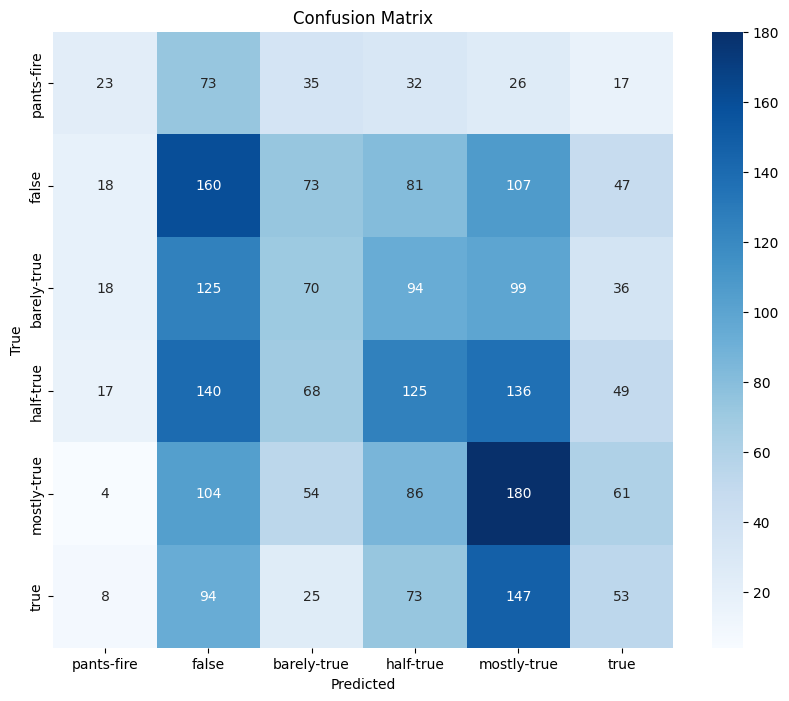

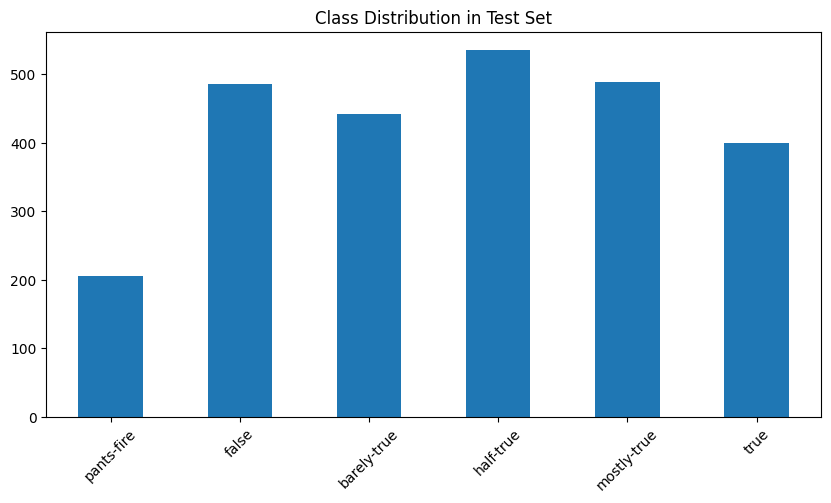

In [ ]:
def visualize_results(test_labels, test_preds, label_order):
    '''
    # classification report
    print("\nClassification Report:")
    print(classification_report(test_labels, test_preds,
                              target_names=label_order,
                              zero_division=0))
    '''

    # confusion matrix
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(test_labels, test_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
               xticklabels=label_order,
               yticklabels=label_order)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # class distribution plot
    plt.figure(figsize=(10, 5))
    pd.Series(test_labels).value_counts().sort_index().plot(kind='bar')
    plt.xticks(ticks=range(len(label_order)), labels=label_order, rotation=45)
    plt.title('Class Distribution in Test Set')
    plt.show()

# call visualization function
label_order = ['pants-fire', 'false', 'barely-true', 'half-true', 'mostly-true', 'true']
visualize_results(test_labels, test_preds, label_order)


From both the evaluation metrics (accuracy, precision, recall, f1-score) and the confusion metrics we make these conclusions:
- The LSTM model is the best at classifying statements which are 'mostly-true': it has a decent precision (0.2590) and the best recall (0.3681) and f1-score (0.3041) amongst all classes
- Meanwhile, the LSTM model performs badly for statements which are 'pants-fire' or 'true'. They have the f1-score of 0.1565 and 0.1599 respectively.
- This is surprising as these classes are the most 'extreme', and we would expect the model to be able to distinguish them better. This suggests that LSTM is not able to distinguish the slight contextual nuances between statements with similar truthfulness. This is also corroborated by the fact that for 'pants-fire', the next most predicted classes after 'pants-fire' is 'false' and 'barely-true', while for 'true', the top 3 most predicted classes are 'true', 'mostly-true', and 'half-true'

# For ensembling: Predicting outputs for all rows in dataset

In [ ]:
# ensure final_model is in evaluation mode
final_model.eval()

# prepare all data for inference
all_data_tokens = tokenize_statements(df_feature_engineered[['statement']])
all_data_indices = convert_to_indices(all_data_tokens, word2idx)
all_data_padded = pad_sequences(all_data_indices, maxlen=max_length)

# convert padded sequences into a DataLoader
full_dataset = FakeNewsDataset(all_data_padded, df_feature_engineered['label_encoded'].values.tolist(), max_len=max_length)
full_loader = DataLoader(full_dataset, batch_size=BATCH_SIZE, shuffle=False)

# extract row IDs from df_feature_engineered
row_ids = df_feature_engineered['id'].values.tolist()

# initialize storage for probabilities and matched row IDs
probabilities = []
matched_ids = []

with torch.no_grad():
    for i, batch in enumerate(full_loader):
        inputs = batch['input_ids'].to(device)

        # perform forward pass
        h = final_model.init_hidden(inputs.size(0))
        outputs, _ = final_model(inputs, h)

        # apply softmax to get probabilities
        probs = torch.softmax(outputs, dim=1).cpu().numpy()

        # match row IDs for this batch using slicing - able to do this since no shuffle and data is processed sequentially
        start_idx = i * BATCH_SIZE
        end_idx = start_idx + inputs.size(0)
        batch_ids = row_ids[start_idx:end_idx]

        # print
        print(f"Batch {i}: Dataset IDs {batch_ids}")

        # Store probabilities and matched IDs
        probabilities.extend(probs.tolist())
        matched_ids.extend(batch_ids)

Batch 0: Dataset IDs ['7874.json', '13412.json', '2287.json', '2426.json', '4832.json', '6090.json', '5766.json', '7875.json', '6303.json', '3967.json', '5473.json', '6476.json', '9387.json', '7178.json', '12631.json', '11959.json']
Batch 1: Dataset IDs ['12233.json', '1694.json', '3676.json', '3784.json', '3818.json', '3926.json', '3932.json', '3931.json', '4092.json', '4262.json', '6767.json', '7004.json', '7003.json', '2509.json', '10141.json', '10525.json']
Batch 2: Dataset IDs ['1768.json', '1769.json', '2369.json', '3169.json', '3629.json', '4729.json', '7040.json', '7707.json', '10725.json', '11865.json', '2728.json', '2440.json', '3253.json', '3750.json', '4156.json', '2254.json']
Batch 3: Dataset IDs ['2289.json', '5215.json', '5692.json', '5758.json', '6208.json', '6751.json', '12909.json', '13326.json', '13140.json', '3806.json', '3805.json', '10851.json', '7480.json', '937.json', '8051.json', '13317.json']
Batch 4: Dataset IDs ['13358.json', '2013.json', '2272.json', '9485.

In [ ]:
# create a DataFrame with probabilities and matched row IDs
probabilities_df = pd.DataFrame(probabilities, columns=[f'class_{i}' for i in range(num_classes)])
probabilities_df['id'] = matched_ids

# save to CSV
output_path = 'lstm_probabilities.csv'
probabilities_df.to_csv(output_path, index=True)

print(f"Probabilities saved to {output_path}")
probabilities_df.head()

Probabilities saved to lstm_probabilities.csv


,class_0,class_1,class_2,class_3,class_4,class_5,id
0,0.116896,0.331581,0.168596,0.143390,0.104744,0.134793,7874.json
1,0.078231,0.288405,0.179340,0.186085,0.137927,0.130011,13412.json
2,0.547955,0.228645,0.110808,0.046633,0.022111,0.043848,2287.json
3,0.067088,0.274327,0.297814,0.242492,0.079598,0.038679,2426.json
4,0.159861,0.459021,0.105772,0.091125,0.097065,0.087156,4832.json
